# Predicting Marketing Success

##### By: Aaron Villegas

## Summary
This project creates predictive machine learning models to identify customers who are likely to subscribe to a term deposit at a bank using the UCI Bank Marketing dataset (40,000+ rows). The logistic regression and random forest models achieved similar performance with accuracy around 83-85% and recall around 0.62. While random forest had slightly higher precision, logistic regression was better suited for interpretability. A practical strategy is to combine both models, using the random forest for predictions and utilizing logistic regression to interpret what influenced the customer's decision to improve future models and marketing strategy. These insights can help optimize marketing campaigns and enhance targeting efficiency. Some insights found were that macroeconomic periods with lower employment variance, high interbank interest rates, and higher consumer price index were a major predictor in marketing success.

An actionable marketing strategy is to first contact the highest-probability customers to avoid false positives (wasted marketing resources) and improve marketing efficiency. 

## Introduction

In this analysis, we will investigate the UCI Bank Marketing dataset to predict whether a client subscribes to a term deposit based on variables such as demographic, education level, job, loan status, country economic status, and other features. A term deposit is a type of investment where the customer deposits some amount of money for a fixed period of time which is then returned with guaranteed interest afterwards. The money is unable to be accessed during the time without penalties. This is a binary classification problem with a large class imbalance, changing how we may want to train a model on the data. In this problem, recall is important since missing potential subscribers is likely more costly than contacting a non-subscriber. We start with exploratory data analysis (EDA) to understand the distributions of the features, their correlations, and whether the data has missing values and requires cleaning.

Then, we will create predictive models using logistic regression as a baseline before performing cross-validation for a more robust result. Next, we will build a random forest classifier and compare performance to identify the most effective model for this problem, using metrics such as accuracy, precision, recall, and ROC AUC. 
The insights discovered can be used to improve marketing strategy, identifying clients that are most likely to subscribe to a term deposit and optimizing marketing campaigns.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math
# Load the dataset
df = pd.read_csv('bank-additional-full.csv', sep=';', quotechar='"')
print(df.head())

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

## Cleaning Data

In [2]:
df.isna().sum().sort_values(ascending=False)

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

We have no 'NA' values found in this dataset, but the dataset does have some "Unknown" values which can carry their own meanings and add information for our models.

In [3]:
# Create new binary variable for never contacted and replace 999 in pdays with 0
df['never_contacted'] = (df['pdays'] == 999).astype(int)
df['pdays'] = df['pdays'].replace(999, 0)
df['poutcome'] = df['poutcome'].fillna("nonexistent")
# Creating unknown category for missing values in categorical variables in case
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna('unknown')

## Plotting Data

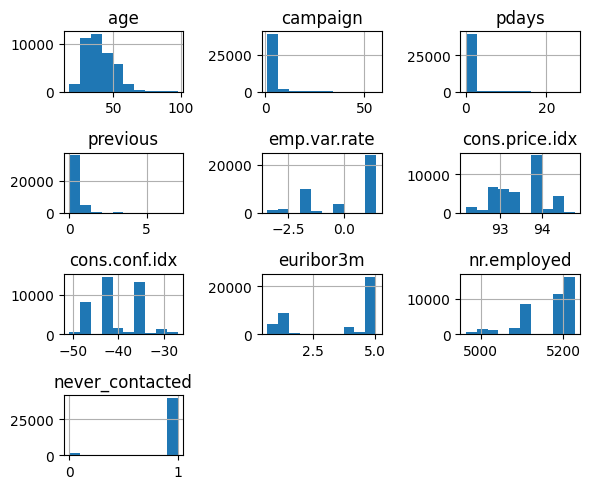

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,never_contacted
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1


In [5]:
# Duration = Time of last call, but if duration =0, then y = no, so we can drop duration to avoid data leakage.
df.drop(columns=['duration'], inplace=True)
df.hist(figsize=(6, 5))
plt.tight_layout()
plt.show()
df.head()

C:\Users\ville\AppData\Local\Temp\ipykernel_9272\3131582435.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


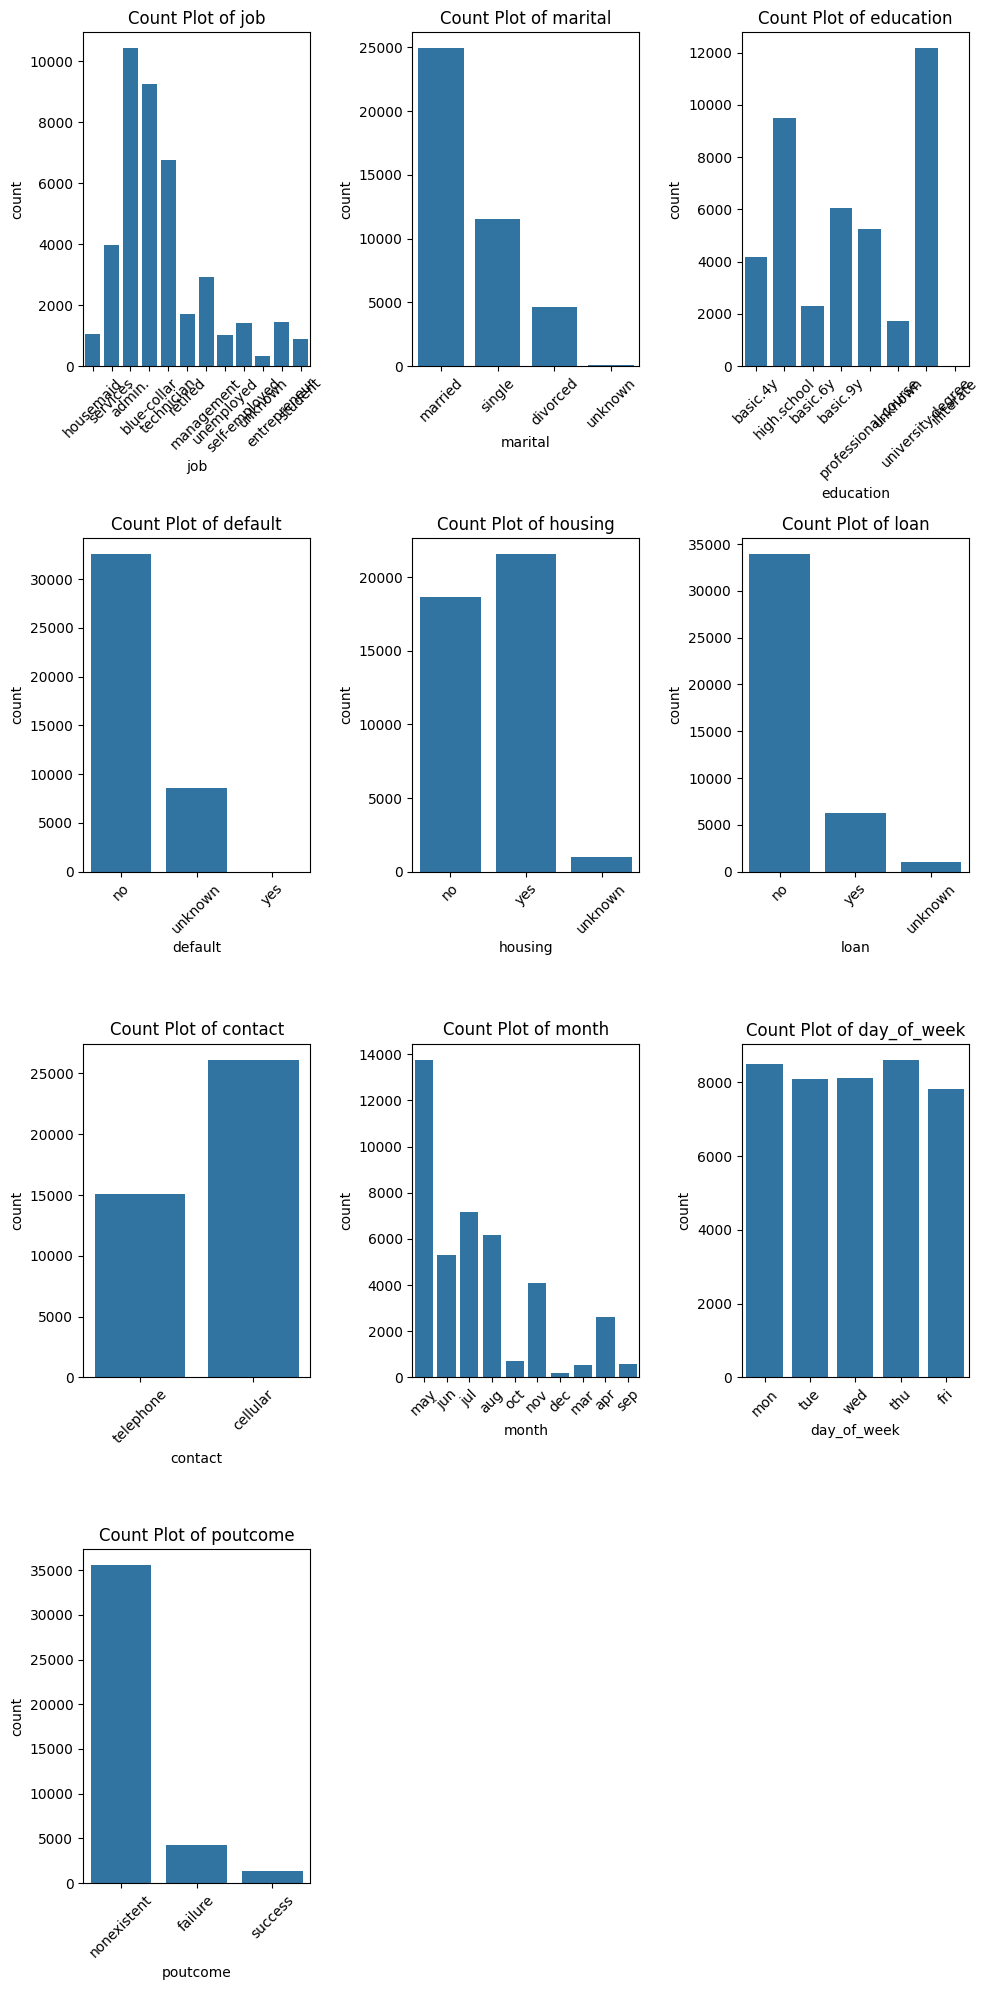

In [5]:
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols = cat_cols.drop('y')  # Exclude target variable from plots

n_cols = 3  # number of plots per row
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Count Plot of {col}')
    axes[i].tick_params(axis='x', rotation=45)

# Remove empty subplots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

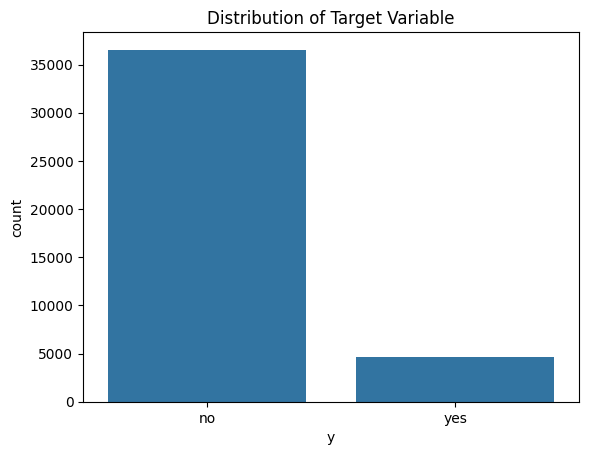

In [6]:
sns.countplot(x="y", data=df)
plt.title("Distribution of Target Variable")
plt.show()

Notice how "yes" is a minority (about 5000 out of 40000 in the dataset). This rarity can change how we train our model since a model can do fairly well by predicting "no."

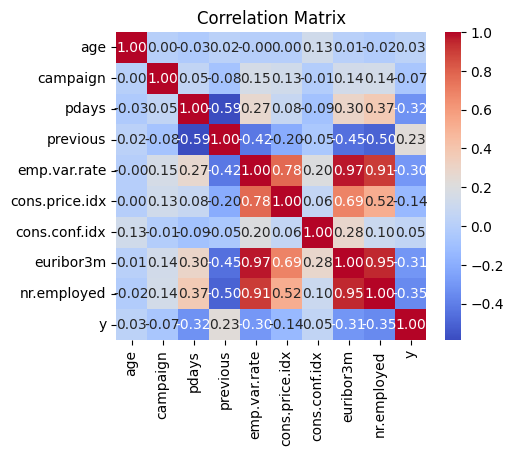

In [41]:
#Adding y after replacing yes/no with 1/0 to include in correlation matrix
df_temp = df.copy()
df_temp['y'] = df_temp['y'].replace({"yes": 1, "no": 0}).astype(int)
corr = df_temp.corr(numeric_only=True)
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

Economic variables, such as emp.var.rate, nr.employed, euribor3m,and cons.price.idx seem to have high correlation with each other, indicating potential multicollinearity. This can affect logistic regression coefficients since the model is not able tell apart the effects of correlated variables, but is less of an issue for random forest. We can see several medium negative correlations with the target variable y, with the highest being nr.employed, pdays, and euribor3m.

## Logistic Regression

First, we will perform regular logistic regression without cross-validation as a baseline since performance may be sensitive to the specific train-test split. Later, we will use cross-validation to better evaluate model performance by averaging performance across multiple train-test splits. Logistic regression is used in this problem because it is widely used for binary classification problems and allows us to interpret the associated coefficients for each variable to assess their importance and influence. 
The performance of the model will be measured with accuracy, precision, recall, and ROC AUC.

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

X_orig = df.drop("y", axis=1)
# Include categorical variables as binary for each category, instead of just string variables
X_log = pd.get_dummies(X_orig, drop_first=True)
y = df["y"].replace({"yes": 1, "no": 0}).astype(
    int)  # Convert target variable to binary
X_train, X_test, y_train, y_test = train_test_split(
    X_log, y, test_size=0.2, random_state=3)


For logistic regression, scaling features is important. Without scaling, features with a large magnitude, such as the number of employees in a country, can dominate other features, leading to less stable coefficient estimates and slower learning. Scaling features to the same scale also gives coefficients with comparable magnitudes.

In [9]:
from sklearn.pipeline import Pipeline
log_reg_model = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(max_iter=10000,
     class_weight='balanced', random_state=3))
])
log_reg_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('log_reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not 

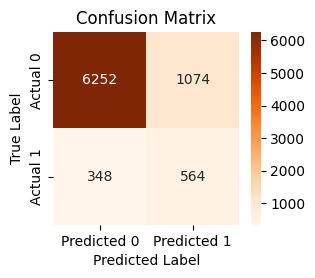

In [10]:
y_pred = log_reg_model.predict(X_test)
confusion = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(3, 2.5))
sns.heatmap(confusion,
            annot=True,
            fmt="d",
            cmap="Oranges",
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

From the confusion matrix above, the model correctly predicts most non-subscribers but struggles with correctly predicting many subscribers (348 missed subscribers). We see a higher number of false negatives (model predicted the customer did not subscribe but actually did) compared to false positives (model predicted the customer did subscribe by actually didn't).

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, f1_score, confusion_matrix

print(f"Accuracy:   {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision:  {precision_score(y_test, y_pred):.2f}")
print(f"Recall:     {recall_score(y_test, y_pred):.2f}")
print(f"ROC AUC:    {roc_auc_score(y_test, y_pred):.2f}")
print(f"F1 Score:   {f1_score(y_test, y_pred):.2f}")

Accuracy:   0.83
Precision:  0.34
Recall:     0.62
ROC AUC:    0.74
F1 Score:   0.44


### Logistic Regression Coefficients

In [12]:
coefficients = pd.DataFrame({
    "Feature": X_log.columns,
    "Coefficient": log_reg_model.named_steps["log_reg"].coef_[0]
})

coefficients_sorted = coefficients.iloc[
    coefficients["Coefficient"].abs().sort_values(ascending=False).index
]
print(coefficients_sorted.head(10))

              Feature  Coefficient
4        emp.var.rate    -2.300390
5      cons.price.idx     1.094774
7           euribor3m     0.612426
37  contact_telephone    -0.321432
9     never_contacted    -0.276284
8         nr.employed     0.243471
38          month_aug     0.214257
41          month_jun    -0.207167
43          month_may    -0.199472
42          month_mar     0.168577


### Cross Validated Logistic Regression

In [13]:
from sklearn.model_selection import cross_validate
cv_model = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(max_iter=10000,
     class_weight='balanced', random_state=3))
])
# Cross-validation on all features
cv_results = cross_validate(cv_model, X_train, y_train, cv=10,
                            scoring=["accuracy", "precision",
                                     "recall", "roc_auc", "f1"],
                            n_jobs=-1)

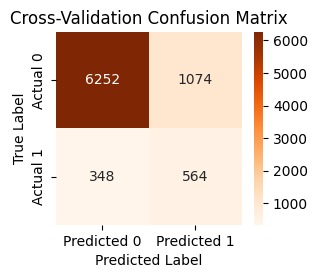

In [14]:

# Uses non-scaled X since scales inside pipeline
cv_model.fit(X_train, y_train)
# Predict on the test set
y_test_pred = cv_model.predict(X_test)

# Compute confusion matrix for the test set
# confusion_test = confusion_matrix(y_test, y_train_pred_cv)
confusion_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(3, 2.5))
sns.heatmap(confusion_test,
            annot=True,
            fmt="d",
            cmap="Oranges",
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Cross-Validation Confusion Matrix")
plt.show()

Notice how the confusion matrix is the same before cross-validating. Cross validating is mainly for finding a more robust estimate of performance and does not change how the logistic regression model is trained.

### Evaluating Cross-Validated Model

In [15]:
print(f"CV Accuracy:   {cv_results['test_accuracy'].mean():.2f}")
print(f"CV Precision:  {cv_results['test_precision'].mean():.2f}")
print(f"CV Recall:     {cv_results['test_recall'].mean():.2f}")
print(f"CV ROC AUC:    {cv_results['test_roc_auc'].mean():.2f}")
print(f"CV F1 Score:   {cv_results['test_f1'].mean():.2f}")

CV Accuracy:   0.83
CV Precision:  0.36
CV Recall:     0.63
CV ROC AUC:    0.79
CV F1 Score:   0.46


#### Precision-Recall Tradeoff

Above are the accuracy metrics for the cross-validated logistic regression model. The model shows moderate accuracy, low precision, high recall, and a moderate ROC Area Under Curve score. In this case, a focus on recall would be more beneficial from a business sense, since a false negative (missing a customer that would have subscribed, missed opportunity cost) is likely more costly than false positives (falsely predicting a customer would subscribe when they don't, costs time/money for marketing efforts). Thus, depending on if marketing is expensive or if the business has a low marketing budget, increasing precision may be beneficial since the business wouldn't want to waste too much time/effort on customers that wouldn't subscribe. This can be done by adjusting the threshold for logistic regression. Since logistic regression predicts a probability of a customer subscribing with a default threshold of 0.5, increasing this threshold to a stricter probability threshold (such as 0.7> for predicting "yes") would decrease recall but increase precision, reducing wasted resources and focusing marketing efforts on those with a higher predicted probability of subscribing.

#### Tuning the Threshold

Instead of using the default 0.5 threshold, we can try different thresholds in order to maximize a performance metrics, such as F1 score or recall. This gives another way to balace precision and recall, and allows us to set a constraint on minimum precision in case the business requires a certain percentage of successful marketing attempts and to avoid wasting too much marketing time/cost on customers that wouldn't subscribe.

In [ ]:
import numpy as np
from sklearn.metrics import precision_recall_curve
y_probs = cv_model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# Keep thresholds where precision >= 0.3
valid = precision >= 0.3

best_idx = valid.nonzero()[0][np.argmax(recall[valid])]

best_threshold = thresholds[best_idx]
y_pred_new = (y_probs >= best_threshold).astype(int)

print(f"Precision: {precision_score(y_test, y_pred_new):.2f}")
print(f"Recall: {recall_score(y_test, y_pred_new):.2f}")
print(f"F1: {f1_score(y_test, y_pred_new):.2f}")
print(f"Best Threshold: {best_threshold:.2f}")

Precision: 0.30
Recall: 0.64
F1: 0.41


## Random Forest Model

Random forests are useful for datasets with non-linear relationships/decision boundaries, which logistic regression may struggle with. By averaging many decision trees, random forests are less prone to overfitting and less vulnerable to outliers. This makes random forests well-suited for this classification problem of predicting client subscriptions and highlighting important features to consider in marketing strategy.

Random forests have hyperparameters, parameters which are not changed when the model is trained. Some of these parameters include the number of estimators (n_estimators), the amount of available features a decision tree can consider to split a node (max_features), the maximum depth of each decision tree (max_depth), and the minimum number of samples per leaf (min_samples_leaf). I set class_weight as 'balanced' since the proportion of "yes" is low compared to the proportion of "no" for customers who subscribed to a term deposit. Without setting it as 'balanced', the model may learn to predict "no" most of the time to get higher accuracy since "yes" is a minority, so 'balanced' gives more importance to the "yes" class. Increasing the number of decision trees reduces variance since there are more decision trees to average from, but increases training time. Setting class_weight to "balanced" reduces the bias from the low amount of data on the minority class of "yes". 

In [17]:
# Test-train split again and one-hot encoding of categorical variables for random forest model
X_train, X_test, y_train, y_test = train_test_split(
    X_log, y, test_size=0.2, random_state=3)
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join='left',
    axis=1,
    fill_value=0
)

### Searching for the best hyperparameters

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_leaf": [1, 2, 5, 10],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", "log2"],
    "class_weight": ["balanced", None]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=3),
    param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

grid.fit(X_train_encoded, y_train)

print("Best parameters:", grid.best_params_)
best_rf = grid.best_estimator_

Best parameters: {'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 10, 'min_samples_split': 2, 'n_estimators': 100}


In [ ]:
#Temporarily using best parameters from previous run to save time, since grid search takes a long time to run with all combinations of parameters
# Best parameters: {'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 200}

best_rf = RandomForestClassifier(class_weight='balanced', max_depth=10, max_features='log2', min_samples_leaf=10, min_samples_split=2, n_estimators=100, random_state=3)

### Random Forest Results

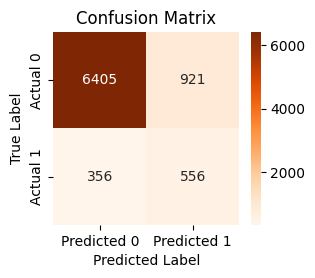

In [19]:
best_rf.fit(X_train_encoded, y_train)
y_pred_rf = best_rf.predict(X_test_encoded)

confusion_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(3, 2.5))
sns.heatmap(confusion_rf,
            annot=True,
            fmt="d",
            cmap="Oranges",
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [20]:
rf_results = cross_validate(
    best_rf,
    X_train_encoded,
    y_train,
    cv=3,
    scoring=["accuracy", "precision", "recall", "roc_auc", "f1"]
)
print("CV Accuracy:", f"{rf_results['test_accuracy'].mean():.2f}")
print("CV Precision:", f"{rf_results['test_precision'].mean():.2f}")
print("CV Recall:", f"{rf_results['test_recall'].mean():.2f}")
print("CV ROC AUC:", f"{rf_results['test_roc_auc'].mean():.2f}")
print("CV F1 Score:", f"{rf_results['test_f1'].mean():.2f}")

CV Accuracy: 0.85
CV Precision: 0.39
CV Recall: 0.62
CV ROC AUC: 0.80
CV F1 Score: 0.48


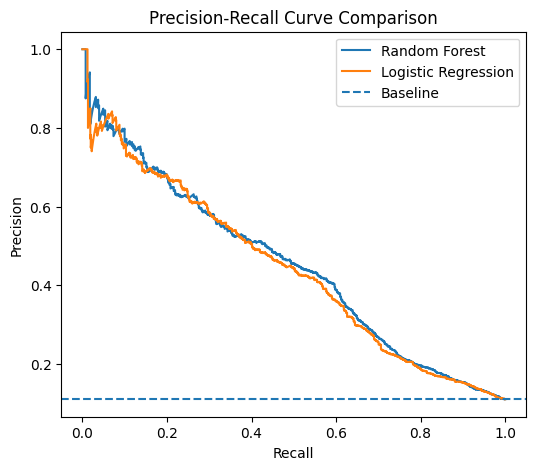

In [35]:
from sklearn.metrics import precision_recall_curve

# --- Random Forest ---
y_probs_rf = best_rf.predict_proba(X_test_encoded)[:, 1]
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_probs_rf)

# --- Logistic Regression ---
y_probs_log = cv_model.predict_proba(X_test)[:, 1]
precision_log, recall_log, _ = precision_recall_curve(y_test, y_probs_log)

# --- Baseline ---
baseline = sum(y_test) / len(y_test)

# --- Plot EVERYTHING in one figure ---
plt.figure(figsize=(6, 5))

plt.plot(recall_rf, precision_rf, label="Random Forest")
plt.plot(recall_log, precision_log, label="Logistic Regression")
plt.axhline(y=baseline, linestyle='--', label="Baseline")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()

plt.show()

For this precision-recall graph, being closer to the top-right corner is best. The random forest model and logistic regression model are roughly equal in terms of precision and recall. The baseline would be a model that always predicts that the customer will subscribe, which can waste time and marketing budget if limited.

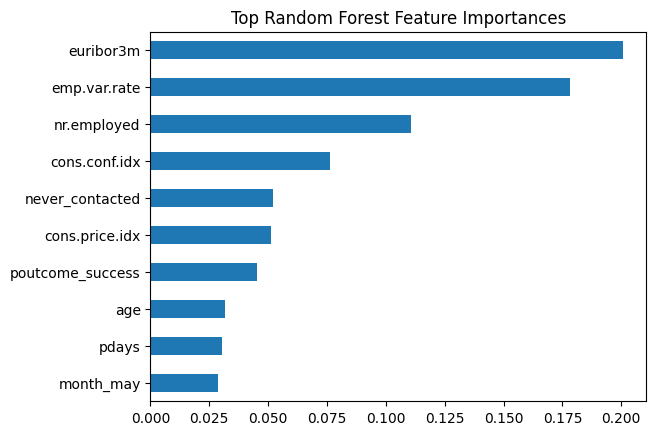

In [21]:
importances = pd.Series(best_rf.feature_importances_,
                        index=X_train_encoded.columns)

importances.sort_values().tail(10).plot(kind="barh")
plt.title("Top Random Forest Feature Importances")
plt.show()

#### Interpreting Random Forest Feature Importance
For the random forest model, the relative importance of a feature indicates how much prediction error a feature reduced compared to other features. Features that often create splits that reduce impurity in the decision trees have higher importance scores.  \
\
The top features were the following:    \
\
&nbsp;&nbsp;&nbsp;&nbsp;**1. euribor3m** (average 3-month interest rate between European banks, economic indicator)  
&nbsp;&nbsp;&nbsp;&nbsp;**2. emp.var.rate** (variability in employment rates)  
&nbsp;&nbsp;&nbsp;&nbsp;**3. nr.employed** (number of employees in the economy during campaign)  
&nbsp;&nbsp;&nbsp;&nbsp;**4. cons.conf.idx** (consumer confidence index)  
&nbsp;&nbsp;&nbsp;&nbsp;**5. never_contacted** (a binary variable indicating the customer was not contacted before) \
&nbsp;&nbsp;&nbsp;&nbsp;**6. cons.price.idx** (consumer price index)  

 \
This indicates that macroeconomic conditions at the time of a marketing campaign were a major indicator whether a customer would subscribe to a term deposit. Previous contact history is also a major indicator. \
\
While feature importance does not indicate whether a feature increases or decreases, context about the variables can indicate what kind of relationship the variable has with predicting term deposit subscriptions. 
\
When interbank interest rates are high (euribor3m), term deposit rates are also higher, making them more appealing for consumers. When there are a higher number of employees in an economy or lower employment variability (indicating economic security), people are less worried about money and tend to view term deposits as less appealing. \
\
Higher consumer confidence (cons.conf.idx) may decrease the want for term deposits as consumers are more confident and may be more willing to take on riskier assets like stocks. Higher price index (cons.price.idx) indicates higher inflation which can decrease the appeal of term deposits if the interest rate and yield is not high enough to outgrow inflation.

## Conclusion

Both models had roughly equal accuracy (83% to 85%) and around 0.62 recall, with the random forest having slightly higher precision, reducing false positives. When choosing between the models, the bank would be choosing between interpretability (logistic regression) and slightly higher performance (random forest).    
When choosing between the models, we have to consider the tradeoff between predictive power and interpretability. Logistic regression gives clear coefficient to interpret to help explain customer behavior. Random forest is best for predicting with non-linear relationships.    
A practical strategy that combines the best of both models is using both. This means deciding based on the random forest and utilizing the logistic regression model to understand the effects of certain features and explaining to managers or stakeholders. Thus, we combine the predictive power and robustness against non-linear patterns of the random forest with the interpretability of logistic regression.  
In a marketing context, interpretability is important for understanding what affects customer decisions which can guide marketing strategy, making logistic regression especially valuable. Based on the feature importances in the random forest model and the coefficients for the logistic regression model, marketing campaigns should focus on periods of low employment variance, high interbank interest rates, and high consumer price index while following up on previously contacted customers.

A valuable marketing strategy is to first contact the customers with the highest probability of subscribing to the term deposit, maximizing the estimated likelihood of a successful marketing campaign and avoiding false positives.

### Model Comparison

| Model | Accuracy | Precision | Recall | ROC AUC | F1 Score |
|------|------|------|------|------|------|
| Logistic Regression | 0.83 | 0.34 | 0.62 | 0.74 | 0.44 |
| Cross Validated Logistic Regression | 0.83 | 0.36 | 0.63 | 0.79 | 0.46 |
| Cross Validated Random Forest | 0.85 | 0.39 | 0.62 | 0.80 | 0.48 |